Defining the percentage of oil that goes below the surface layer in the Haro Boundary region, for use in Atlantis dilbit spills. Based on original notebook from Susan Allen as part of the MIDOSS project.

In [11]:
import copy
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

%matplotlib inline

In [4]:
plt.rcParams.update({'font.size': 13})

In [5]:
thefile = '/data/sallen/MIDOSS/aggregated_spills_files/fiftieth_55_oils.nc'
oil = xr.open_dataset(thefile)
whichspills = "All Oil Spills"
smalloils = 113 + 54

In [7]:
mesh = xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask201702.nc')
tmask = 1- mesh.tmask[0, 0]
divarea = 1/(mesh.e1t[0, 1:-1, 1:-1] * mesh.e2t[0, 1:-1, 1:-1])
alength = 1/np.maximum(mesh.e1t[0, 1:-1:, 1:-1], mesh.e2t[0, 1:-1, 1:-1])
mesh.close()

In [8]:
imin = 0
jmin, jmax = 0, 398
imax = imin + (jmax - jmin)*2/500*440
imax = 898
aspect = 500/440

In [9]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=-1):
    if n == -1:
        n = cmap.N
    new_cmap = colors.LinearSegmentedColormap.from_list(
         'trunc({name},{a:.2f},{b:.2f})'.format(name=cmap.name, a=minval, b=maxval),
         cmap(np.linspace(minval, maxval, n)))
    return new_cmap

In [13]:
minColor = 0.1
maxColor = 0.85
need = 4   # need four values at a point to calculate quartiles

### Surface oil

In [14]:
ma_oil_pres = np.ma.masked_array(oil.oilpresence, oil.oilpresence == 0)

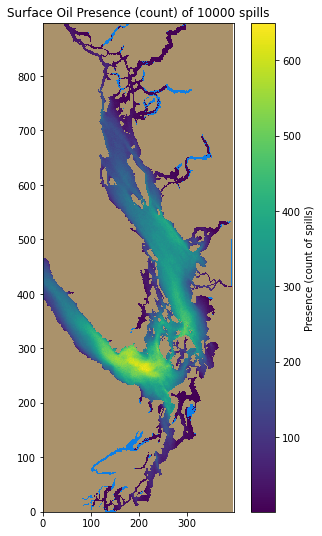

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(6, 9))

ax.pcolormesh(tmask[1:, 1:], cmap='terrain', vmin=-0.2, vmax=1.6)
ax.set_ylim(imin, imax)
ax.set_xlim(jmin, jmax)
ax.set_aspect(aspect)


C = ax.pcolormesh(ma_oil_pres, zorder=2,)# cmap='gist_ncar')
cb = fig.colorbar(C, ax=ax);    
cb.set_label('Presence (count of spills)')
ax.set_title(f'Surface Oil Presence (count) of {oil.nofiles.values+smalloils} spills');   

Surface oil volume

In [20]:
absol = 0.5
perol = 0.25
eps = 1e-7
mcsize = 49

bt_absol = absol
bt_perol = perol

In [21]:
ma_surface_oil = np.ma.masked_array(oil.surface_oil[0]/(oil.oilpresence + eps), 
                                    oil.oilpresence == 0)

surfoil_25 = np.quantile(oil.surface_oil/(oil.oilpresence + eps), 0.25, axis=0)
surfoil_75 = np.quantile(oil.surface_oil/(oil.oilpresence + eps), 0.75, axis=0)

surfoiled = np.ma.masked_array(oil.surface_oil[0]/(oil.oilpresence + eps), 
                               (oil.oilpresence < need) | (
    (np.exp(surfoil_75) - np.exp(surfoil_25) > np.exp(ma_surface_oil)) )) 

ma_surfoil_del = np.ma.masked_array(np.exp(surfoil_75) - 
                                    np.exp(surfoil_25), oil.oilpresence < need)

print (ma_surface_oil.max(), surfoil_75.max())

7.129695074040375 14.055608038963308


-2.4059573249851707
-2.5094133268194367 -2.281914583505342
del 0.02077263128325449 0.5
<xarray.DataArray 'oilpresence' ()>
array(279.)
Coordinates:
    grid_x   int64 300
    grid_y   int64 400
    grid_z   int16 ...
* -2.4059573249851707
3.938589436774221
0.014136484929468304
****
0.09017912354520241
0.0813159311256929 0.10208856240894738
0.02077263128325449


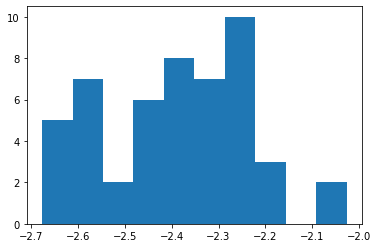

In [22]:
plt.hist(oil.surface_oil[:, 400, 300]/(oil.oilpresence[400, 300] + eps))

print (ma_surface_oil[400, 300])
print (surfoil_25[400, 300], surfoil_75[400, 300])

print ('del', ma_surfoil_del[400, 300], absol)
print (oil.oilpresence[400, 300])
print ('*', surfoiled[400, 300])
print (np.exp(surfoiled.max()))
print (np.exp(surfoiled.min()))

print ('****')
print (np.exp(ma_surface_oil[400, 300]))
print (np.exp(surfoil_25[400, 300]), np.exp(surfoil_75[400, 300]))
print (np.exp(surfoil_75[400, 300]) - np.exp(surfoil_25[400, 300]))

### Deep oil

In [39]:
ma_deep_pres = np.ma.masked_array(oil.deeppresence, oil.deeppresence == 0)

In [23]:
absol = 5
perol = 0.25

wd_absol = absol
wd_perol = perol

In [24]:
	
ma_deep_location = np.ma.masked_array(oil.deep_location[0]/(oil.deeppresence + eps), 
                                      oil.deeppresence == 0)
print (oil.deep_location.shape)
location_25 = np.quantile(oil.deep_location/(oil.deeppresence + eps), 0.25, axis=0)
location_75 = np.quantile(oil.deep_location/(oil.deeppresence + eps), 0.75, axis=0)
print (location_25.shape)

location = np.ma.masked_array(oil.deep_location[0]/(oil.deeppresence + eps), 
                              (oil.deeppresence < need) | (
    (location_75 - location_25 > absol) 
    & (location_75 - location_25 > perol*ma_deep_location))) 

ma_location_del = np.ma.masked_array(location_75 - location_25, oil.deeppresence < need)

print (ma_deep_location.max())

(50, 896, 396)
(896, 396)
279.9262886394291


55.88931975981047 <xarray.DataArray 'deeppresence' ()>
array(378.)
Coordinates:
    grid_x   int64 300
    grid_y   int64 350
    grid_z   int16 ...


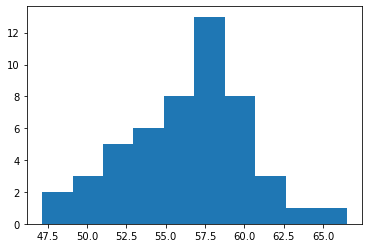

In [26]:
plt.hist(oil.deep_location[:, 350, 300]/oil.deeppresence[350, 300]);
print (ma_deep_location[350, 300], oil.deeppresence[350, 300])

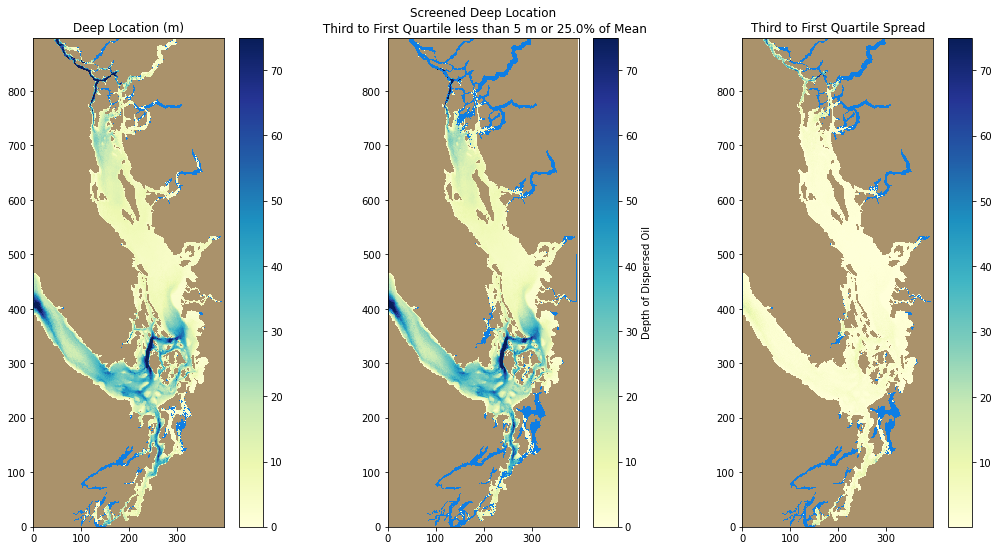

In [32]:
fig, axs = plt.subplots(1, 3, figsize=(18, 9))

for ax in axs:
    ax.pcolormesh(tmask[1:, 1:], cmap='terrain', vmin=-0.2, vmax=1.6)
    ax.set_ylim(imin, imax)
    ax.set_xlim(jmin, jmax)
    ax.set_aspect(aspect)

C = axs[0].pcolormesh(
     ma_deep_location,
    zorder=2, vmin=0, vmax=75, cmap=cm.YlGnBu
)
cb = fig.colorbar(C, ax=axs[0]);    
axs[0].set_title('Deep Location (m)');    

C = axs[1].pcolormesh(
     location,
    zorder=2, vmin=0, vmax=75, cmap=cm.YlGnBu
)
cb = fig.colorbar(C, ax=axs[1]);
cb.set_label('Depth of Dispersed Oil')
axs[1].set_title(
    f'Screened Deep Location\n Third to First Quartile less than {wd_absol} m or {wd_perol*100}% of Mean')

C = axs[2].pcolormesh(ma_location_del, 
    zorder=2, vmax=75, cmap=cm.YlGnBu
)
cb = fig.colorbar(C, ax=axs[2]);
axs[2].set_title('Third to First Quartile Spread');

Deep oil volume

In [33]:
ma_deep_oil = np.ma.masked_array(oil.deep_oil[0]/(oil.deeppresence + eps), 
                                 oil.deeppresence == 0)

deepoil_25 = np.quantile(oil.deep_oil/(oil.deeppresence + eps), 0.25, axis=0)
deepoil_75 = np.quantile(oil.deep_oil/(oil.deeppresence + eps), 0.75, axis=0)

deepoiled = np.ma.masked_array(oil.deep_oil[0]/(oil.deeppresence + eps), 
                               (oil.deeppresence < need) | (
    (np.exp(deepoil_75) - np.exp(deepoil_25) > np.exp(ma_deep_oil)) )) 

ma_deepoil_ste = np.ma.masked_array(np.exp(deepoil_75) 
                                    - np.exp(deepoil_25), oil.deeppresence < need)

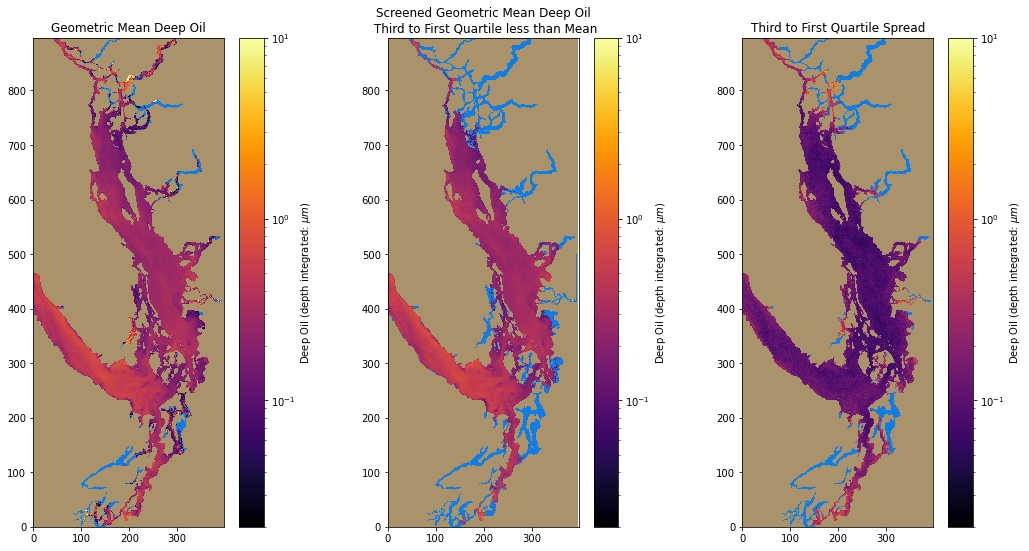

In [34]:
fig, axs = plt.subplots(1, 3, figsize=(18, 9))

vmin, vmax = 0.02, 10

for ax in axs:
    ax.pcolormesh(tmask[1:, 1:], cmap='terrain', vmin=-0.2, vmax=1.6)
    ax.set_xlim(jmin, jmax)
    ax.set_aspect(aspect)


C = axs[0].pcolormesh(
     np.exp(ma_deep_oil) * divarea * 1e6, norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    zorder=2, cmap='inferno'
)
cb = fig.colorbar(C, ax=axs[0]);    
cb.set_label('Deep Oil (depth integrated: $\mu m$)')
axs[0].set_title('Geometric Mean Deep Oil')
    
C = axs[1].pcolormesh(
     np.exp(deepoiled) * divarea * 1e6,
    zorder=2, norm=colors.LogNorm(vmin=vmin, vmax=vmax), cmap='inferno'
)
cb = fig.colorbar(C, ax=axs[1]);
cb.set_label('Deep Oil (depth integrated: $\mu m$)')
axs[1].set_title(
    f'Screened Geometric Mean Deep Oil\n Third to First Quartile less than Mean')

C = axs[2].pcolormesh(
     ma_deepoil_ste
     * divarea * 1e6, norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    zorder=2, cmap='inferno'
)
cb = fig.colorbar(C, ax=axs[2]);
cb.set_label('Deep Oil (depth integrated: $\mu m$)')
axs[2].set_title('Third to First Quartile Spread');

### Comparison

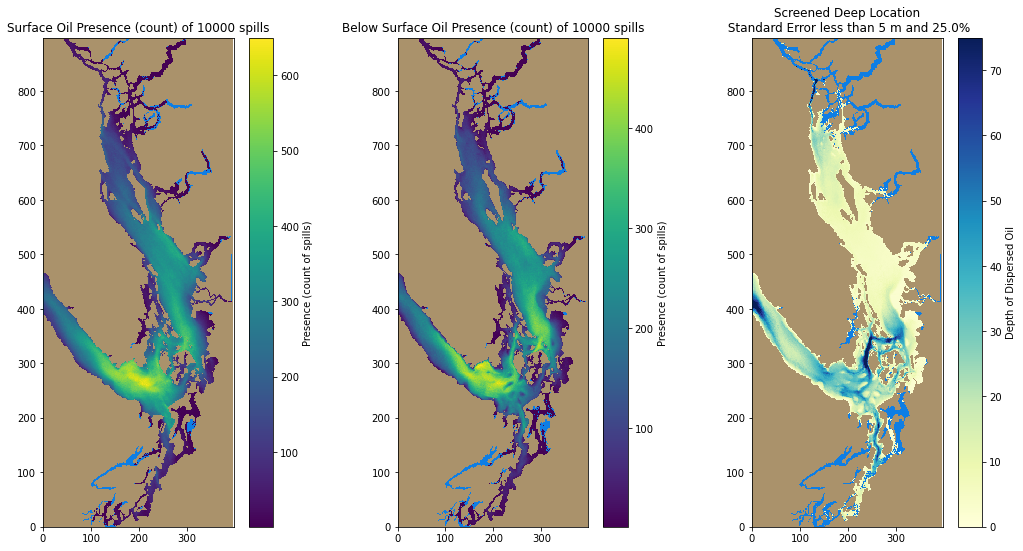

In [44]:
fig, axs = plt.subplots(1, 3, figsize=(18, 9))

for ax in axs:
    ax.pcolormesh(tmask[1:, 1:], cmap='terrain', vmin=-0.2, vmax=1.6)
    ax.set_ylim(imin, imax)
    ax.set_xlim(jmin, jmax)
    ax.set_aspect(aspect)
        
C = axs[0].pcolormesh(ma_oil_pres, zorder=2)
cb = fig.colorbar(C, ax=axs[0]);    
cb.set_label('Presence (count of spills)')
axs[0].set_title(
    f'Surface Oil Presence (count) of {oil.nofiles.values+smalloils} spills');  

C = axs[1].pcolormesh(ma_deep_pres, zorder=2)
cb = fig.colorbar(C, ax=axs[1]);    
cb.set_label('Presence (count of spills)')
axs[1].set_title(
    f'Below Surface Oil Presence (count) of {oil.nofiles.values+smalloils} spills');   

C = axs[2].pcolormesh(
     location,
    zorder=2, vmin=0, vmax=75, cmap=cm.YlGnBu
)
cb = fig.colorbar(C, ax=axs[2]);
cb.set_label('Depth of Dispersed Oil')
axs[2].set_title(
    f'Screened Deep Location\n Standard Error less than {wd_absol} m and {wd_perol*100}%');

In [45]:
location.shape, ma_deep_pres.shape

((896, 396), (896, 396))

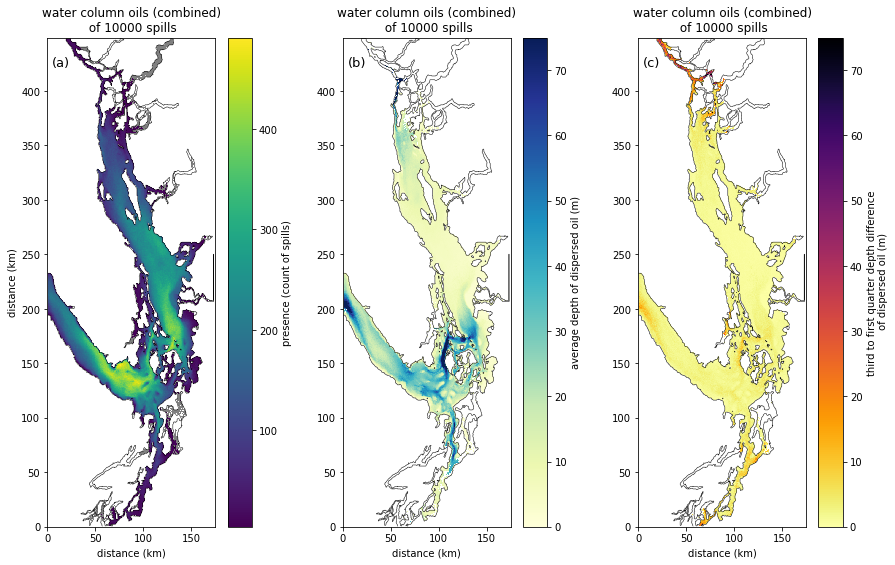

In [47]:
mylabels = ['(a)', '(b)', '(c)']

fig, axs = plt.subplots(1, 3, figsize=(15, 9))

minnum_spills = 4

for iax, ax in enumerate(axs):
    ax.contour(np.arange(jmin+1, jmax)*0.440, np.arange(imin+1, imax)*0.500, tmask[1:, 1:], 
              levels=[0.5], colors=['k'], linewidths=[0.5], zorder=5)
    ax.set_ylim(imin*0.500, imax*0.500)
    ax.set_xlim(jmin*0.44, jmax*0.44)
    ax.set_aspect(aspect)
    ax.set_xlabel('distance (km)')
    ax.text(5, 420, mylabels[iax],
            fontsize=13, verticalalignment='bottom',
            )
    ax.set_title(
    f'water column oils (combined)\n of {oil.nofiles.values+smalloils} spills');
axs[0].set_ylabel('distance (km)')


cmap = copy.copy(plt.get_cmap('viridis'))
cmap.set_under('grey')
C = axs[0].pcolormesh(np.arange(jmin+1, jmax)*0.440, np.arange(imin+1, imax)*0.500, ma_deep_pres, zorder=2,
                     vmin=minnum_spills, cmap=cmap)
cb = fig.colorbar(C, ax=axs[0]);    
cb.set_label('presence (count of spills)')

filter_location = copy.copy(location)
filter_location[ma_deep_pres < minnum_spills] = -1

cmap = copy.copy(cm.YlGnBu)
cmap.set_under('w')
C = axs[1].pcolormesh(np.arange(jmin+1, jmax)*0.440, np.arange(imin+1, imax)*0.500,
     filter_location,
    zorder=2, vmin=0, vmax=75, cmap=cmap
)
cb = fig.colorbar(C, ax=axs[1]);
cb.set_label('average depth of dispersed oil (m)')


filter_del = copy.copy(ma_location_del)
filter_del[ma_deep_pres < minnum_spills] = -1

cmap = copy.copy(cm.inferno_r)
cmap.set_under('w')

C = axs[2].pcolormesh(np.arange(jmin+1, jmax)*0.440, np.arange(imin+1, imax)*0.500, filter_del, 
    zorder=2, vmax=75, cmap=cmap, vmin=0
)
cb = fig.colorbar(C, ax=axs[2]);
cb.set_label('third to first quarter depth difference\n of dispersed oil (m)')
fig.savefig('Waterdepth_figure.pdf');
